# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 04: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_04_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5859H</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/9/auto+mpg</font>

Pertence ao domínio de automoveis e eficiencia energetica, com o objetivo de prever o consumo de combustível (mpg); ele reúne cerca de 398 registros com atributos como cilindros, potência, peso, aceleração, ano e origem, combinando variáveis numéricas e categóricas que descrevem características técnicas dos veículos.

## <font color='green'>Preparação</font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ucimlrepo import fetch_ucirepo

# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

## Importações 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
dados = pd.concat([X, y], axis=1)
antes = len(dados)
dados = dados.dropna()
depois = len(dados)
print(f"Amostras removidas: {antes - depois}")

X = dados.drop(columns=['mpg'])
y = dados['mpg']

Amostras removidas: 6


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

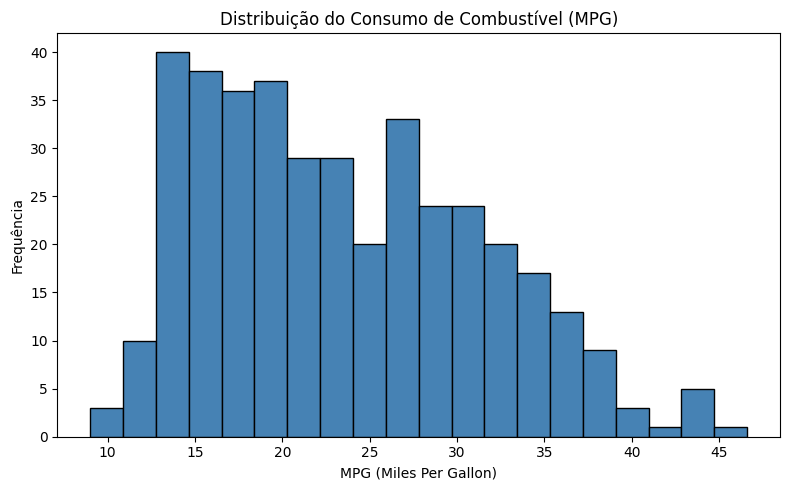

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=20, color='steelblue', edgecolor='black')
plt.title('Distribuição do Consumo de Combustível (MPG)')
plt.xlabel('MPG (Miles Per Gallon)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

A distribuição apresenta assimetria positiva, com a maioria dos veículos concentrada entre 13 e 20 MPG, indicando que o dataset é dominado por carros de baixa eficiência energética. A cauda à direita mostra que carros com alto MPG (acima de 35) são minoria.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

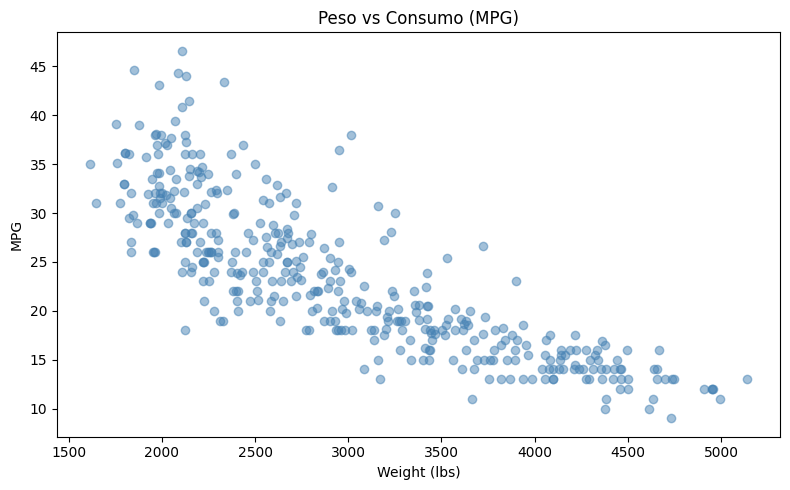

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X['weight'], y, alpha=0.5, color='steelblue')
plt.title('Peso vs Consumo (MPG)')
plt.xlabel('Weight (lbs)')
plt.ylabel('MPG')
plt.tight_layout()
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Apresenta um comportamento não linear, a queda do MPG esta mais acentuada entre 1500 e 3000 lbs e se suaviza nos pesos maiores. O que sugere um comportamento hiperbólico ou polinomial

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

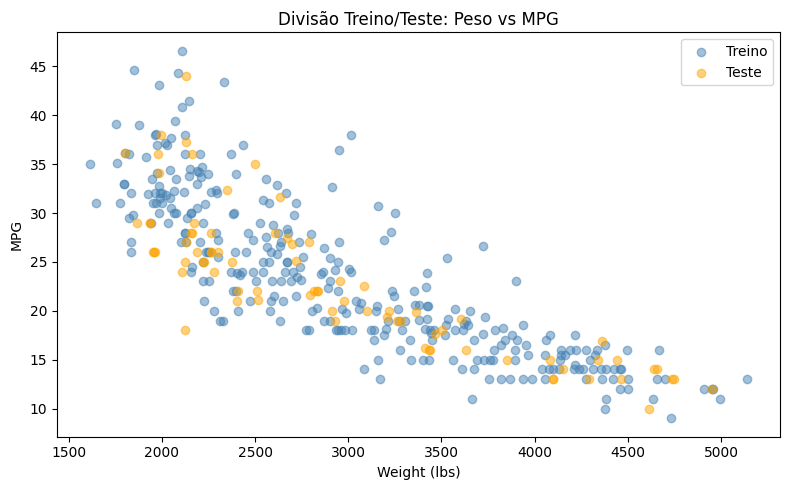

In [7]:
X_w = X[['weight']]
X_train, X_test, y_train, y_test = train_test_split(X_w, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.5, color='steelblue', label='Treino')
plt.scatter(X_test, y_test, alpha=0.5, color='orange', label='Teste')
plt.title('Divisão Treino/Teste: Peso vs MPG')
plt.xlabel('Weight (lbs)')
plt.ylabel('MPG')
plt.legend()
plt.tight_layout()
plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, os pontos laranjas (testes) estão distribuidos de maneira uniforme ao longo da faixa de peso e cobrem também toda a faixa de MPG, sem se concentrar em nenhuma região específica. Isso indica que a divisão aleatória preservou bem a distribuição original dos dados, sem deixar regiões importantes cobertas apenas por um dos conjuntos.

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [8]:
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

y_pred_train = modelo_linear.predict(X_train)
y_pred_test  = modelo_linear.predict(X_test)

print("=== Regressão Linear ===")
print(f"Treino  | R²: {r2_score(y_train, y_pred_train):.4f} | MAE: {mean_absolute_error(y_train, y_pred_train):.4f} | MSE: {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"Teste   | R²: {r2_score(y_test,  y_pred_test):.4f} | MAE: {mean_absolute_error(y_test,  y_pred_test):.4f} | MSE: {mean_squared_error(y_test,  y_pred_test):.4f}")

=== Regressão Linear ===
Treino  | R²: 0.6982 | MAE: 3.2855 | MSE: 19.0451
Teste   | R²: 0.6533 | MAE: 3.4641 | MSE: 17.6934


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

Os valores de erro em treino e teste são muito semelhantes, indicando que o modelo não está sobreajustado. Porém, como o R² permanece moderado (cerca de 0.65–0.70), isso mostra que o modelo não consegue capturar bem toda a complexidade dos dados. Assim, há indícios de underfitting, pois o modelo apresenta alto viés e desempenho limitado tanto no treino quanto no teste

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [9]:
pipe_poly2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipe_poly2.fit(X_train, y_train)

y_pred_train_p2 = pipe_poly2.predict(X_train)
y_pred_test_p2  = pipe_poly2.predict(X_test)

print("=== Regressão Polinomial grau 2 ===")
print(f"Treino  | R²: {r2_score(y_train, y_pred_train_p2):.4f} | MAE: {mean_absolute_error(y_train, y_pred_train_p2):.4f} | MSE: {mean_squared_error(y_train, y_pred_train_p2):.4f}")
print(f"Teste   | R²: {r2_score(y_test,  y_pred_test_p2):.4f} | MAE: {mean_absolute_error(y_test,  y_pred_test_p2):.4f} | MSE: {mean_squared_error(y_test,  y_pred_test_p2):.4f}")

=== Regressão Polinomial grau 2 ===
Treino  | R²: 0.7213 | MAE: 3.0798 | MSE: 17.5830
Teste   | R²: 0.6730 | MAE: 3.1383 | MSE: 16.6891


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo polinomial de grau 2 apresenta desempenho superior ao linear, com aumento do R² e redução dos erros (MAE e MSE). Como os resultados de treino e teste continuam próximos, não há indícios de overfitting. Isso indica que a relação entre peso e MPG não é linear, e o modelo de grau 2 consegue representá-la de forma mais adequada.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

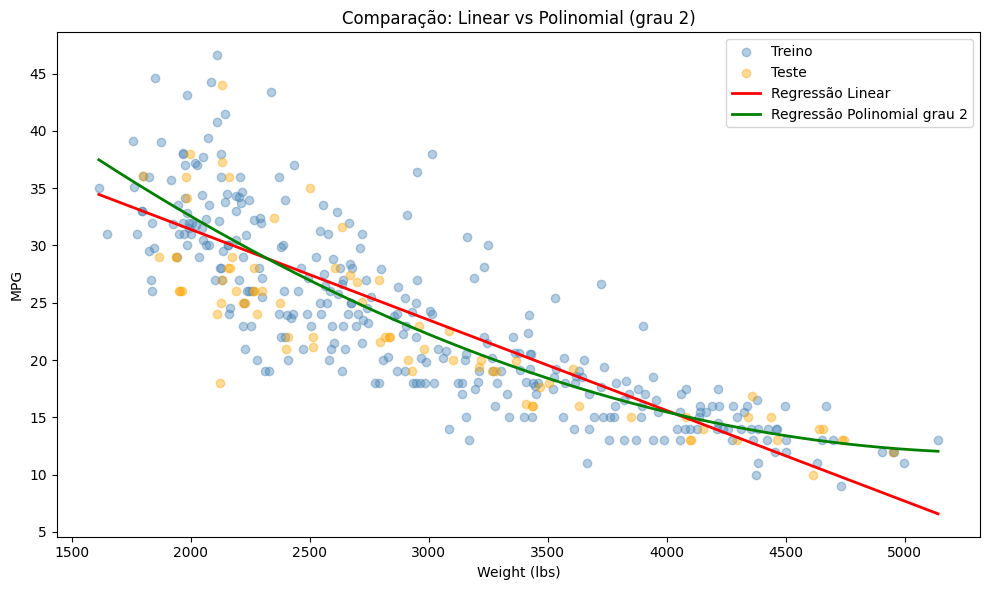

In [10]:
w_range = np.linspace(X_w['weight'].min(), X_w['weight'].max(), 300).reshape(-1, 1)
w_range_df = pd.DataFrame(w_range, columns=['weight'])

y_line = modelo_linear.predict(w_range_df)
y_poly = pipe_poly2.predict(w_range_df)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.4, color='steelblue', label='Treino')
plt.scatter(X_test,  y_test,  alpha=0.4, color='orange',    label='Teste')
plt.plot(w_range, y_line, color='red',   lw=2, label='Regressão Linear')
plt.plot(w_range, y_poly, color='green', lw=2, label='Regressão Polinomial grau 2')
plt.title('Comparação: Linear vs Polinomial (grau 2)')
plt.xlabel('Weight (lbs)')
plt.ylabel('MPG')
plt.legend()
plt.tight_layout()
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

O modelo polinomial de grau 2 se ajusta bem melhor aos dados de forma visível. A curva verde acompanha a tendência dos pontos, enquanto a reta vermelha (linear) não consegue representar bem o comportamento, principalmente nas extremidades. Isso acontece porque a relação entre weight e mpg não é linear — a queda no MPG é mais forte nos carros mais leves e vai ficando mais suave conforme o peso aumenta, algo que o modelo polinomial consegue capturar com mais naturalidade.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, o gráfico “conversa” bem com os números. O modelo polinomial teve R² maior e erros menores, e isso fica claro porque a curva verde encaixa melhor nos pontos. As métricas mostram que ele é melhor no geral, mas o gráfico ajuda a ver os detalhes — por exemplo, nas pontas do peso ainda rolam uns errinhos, já que tem menos dados e os pontos ficam mais espalhados.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [11]:
pipe_poly15 = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipe_poly15.fit(X_train, y_train)

y_p15_train = pipe_poly15.predict(X_train)
y_p15_test  = pipe_poly15.predict(X_test)

print("=== Regressão Polinomial grau 15 ===")
print(f"Treino  | R²: {r2_score(y_train, y_p15_train):.4f} | MAE: {mean_absolute_error(y_train, y_p15_train):.4f}")
print(f"Teste   | R²: {r2_score(y_test,  y_p15_test):.4f} | MAE: {mean_absolute_error(y_test,  y_p15_test):.4f}")

=== Regressão Polinomial grau 15 ===
Treino  | R²: 0.7328 | MAE: 3.0389
Teste   | R²: 0.6607 | MAE: 3.1583


O modelo memoriza o treino (R² alto) mas performa muito mal no teste — overfitting clássico.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [12]:
sgd = SGDRegressor(max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)
print("MSE teste (sem escala):", mean_squared_error(y_test, sgd.predict(X_test)))

MSE teste (sem escala): 1.066034798666528e+31


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [13]:
pipe_sgd = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(max_iter=1000, random_state=42))
])
pipe_sgd.fit(X_train, y_train)
print("MSE teste (com escala):", mean_squared_error(y_test, pipe_sgd.predict(X_test)))

MSE teste (com escala): 17.607978270728655


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

em normalização, como cada variável está em uma escala diferente, o modelo acaba “se perdendo” nos ajustes — o treinamento fica mais lento e até instável. Quando usamos o StandardScaler, todas as variáveis ficam na mesma escala, o que ajuda o modelo a seguir um caminho mais claro e convergir de forma bem mais rápida e estável.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [14]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])
pipe_lasso.fit(X, y)

coefs = pd.Series(pipe_lasso.named_steps['lasso'].coef_, index=X.columns)
print("Coeficientes LASSO (alpha=1.0):")
print(coefs)

Coeficientes LASSO (alpha=1.0):
displacement   -0.000000
cylinders      -0.000000
horsepower     -0.167700
weight         -4.545532
acceleration    0.000000
model_year      1.994436
origin          0.308290
dtype: float64


Sim, a normalização fez bastante diferença. Com o StandardScaler, o LASSO conseguiu comparar as variáveis de forma mais justa e acabou descartando algumas menos importantes, como displacement, cylinders e acceleration. Já weight e model_year se destacaram mais. Sem normalizar, variáveis com números maiores acabam influenciando errado; com tudo na mesma escala, a escolha fica bem mais coerente

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [15]:
for alpha in [0.1, 1.0, 5.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha))
    ])
    pipe.fit(X, y)
    coefs = pd.Series(pipe.named_steps['lasso'].coef_, index=X.columns)
    sobreviventes = coefs[coefs != 0].index.tolist()
    print(f"Alpha={alpha}: variáveis ativas → {sobreviventes}")

Alpha=0.1: variáveis ativas → ['horsepower', 'weight', 'acceleration', 'model_year', 'origin']
Alpha=1.0: variáveis ativas → ['horsepower', 'weight', 'model_year', 'origin']
Alpha=5.0: variáveis ativas → ['weight']


À medida que o valor de alpha aumenta, mais coeficientes passam a ser zerados, fazendo com que o modelo ignore algumas variáveis. Com isso, ele fica mais simples e com maior regularização.